In [2]:
import pandas



In [3]:


data_path = '/home/jon/projects/leaf-clustering-random-forests/data/processed/pamap2.parquet'
data = pandas.read_parquet(data_path)
data

activity  heartrate  hand_temperature  \
subject    time                                                             
subject105 0 days 00:00:05.700000  transient        NaN           34.0000   
           0 days 00:00:05.710000  transient        NaN           34.0000   
           0 days 00:00:05.720000  transient        NaN           34.0000   
           0 days 00:00:05.730000  transient        NaN           34.0000   
           0 days 00:00:05.740000  transient        NaN           34.0000   
...                                      ...        ...               ...   
subject103 0 days 00:42:13.920000  transient        NaN           28.0625   
           0 days 00:42:13.930000  transient        NaN           28.0625   
           0 days 00:42:13.940000  transient        NaN           28.0625   
           0 days 00:42:13.950000  transient        NaN           28.0625   
           0 days 00:42:13.960000  transient      107.0           28.0625   

                                   hand_acceleration_16g_x  \
subject    time                                              
subject105 0 days 00:00:05.700000                  2.22755   
           0 days 00:00:05.710000                  2.37550   
           0 days 00:00:05.720000                  2.94208   
           0 days 00:00:05.730000                  3.47541   
           0 days 00:00:05.740000                  3.54617   
...                                                    ...   
subject103 0 days 00:42:13.920000                  1.41225   
           0 days 00:42:13.930000                  1.66233   
           0 days 00:42:13.940000                  1.87676   
           0 days 00:42:13.950000                  1.98797   
           0 days 00:42:13.960000                  2.01215   

                                   hand_acceleration_16g_y  \
subject    time                                              
subject105 0 days 00:00:05.700000                  9.65418   
           0 days 00:00:05.710000                  9.57647   
           0 days 00:00:05.720000                  9.53415   
           0 days 00:00:05.730000                  9.75837   
           0 days 00:00:05.740000                  9.83232   
...                                                    ...   
subject103 0 days 00:42:13.920000                  7.77957   
           0 days 00:42:13.930000                  7.62242   
           0 days 00:42:13.940000                  8.14779   
           0 days 00:42:13.950000                  8.79021   
           0 days 00:42:13.960000                  7.61246   

                                   hand_acceleration_16g_z  \
subject    time                                              
subject105 0 days 00:00:05.700000                 2.388620   
           0 days 00:00:05.710000                 2.314120   
           0 days 00:00:05.720000                 2.322750   
           0 days 00:00:05.730000                 2.406960   
           0 days 00:00:05.740000                 2.253820   
...                                                    ...   
subject103 0 days 00:42:13.920000                -0.041973   
           0 days 00:42:13.930000                -0.422570   
           0 days 00:42:13.940000                -0.882979   
           0 days 00:42:13.950000                -1.075920   
           0 days 00:42:13.960000                -1.225530   

                                   hand_acceleration_6g_x  \
subject    time                                             
subject105 0 days 00:00:05.700000                2.319680   
           0 days 00:00:05.710000                2.456570   
           0 days 00:00:05.720000                2.788760   
           0 days 00:00:05.730000                3.330800   
           0 days 00:00:05.740000                3.676420   
...                                                   ...   
subject103 0 days 00:42:13.920000                0.970555   
           0 days 00:42:13.930000                1.435440   
   

In [9]:
durations = data.reset_index().groupby('subject')['time'].max()
durations

/tmp/ipykernel_1683312/822637258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  durations = data.reset_index().groupby('subject')['time'].max()


subject
subject101   0 days 01:02:52.540000
subject102   0 days 01:14:35.630000
subject103   0 days 00:42:13.960000
subject104   0 days 00:55:01.460000
subject105   0 days 01:02:33.520000
subject106   0 days 01:00:24.050000
subject107   0 days 00:52:21.900000
subject108   0 days 01:08:06.190000
subject109   0 days 00:01:40.230000
Name: time, dtype: timedelta64[ns]

In [10]:
durations.sum()

Timedelta('0 days 07:59:49.480000')

In [60]:
#data.columns

In [12]:
data.dtypes

activity                               category
heartrate                               float64
hand_temperature                        float64
hand_acceleration_16g_x                 float64
hand_acceleration_16g_y                 float64
hand_acceleration_16g_z                 float64
hand_acceleration_6g_x                  float64
hand_acceleration_6g_y                  float64
hand_acceleration_6g_z                  float64
hand_gyro_x                             float64
hand_gyro_y                             float64
hand_gyro_z                             float64
hand_magnetometer_x                     float64
hand_magnetometer_y                     float64
hand_magnetometer_z                     float64
chest_hand_temperature                  float64
chest_hand_acceleration_16g_x           float64
chest_hand_acceleration_16g_y           float64
chest_hand_acceleration_16g_z           float64
chest_hand_acceleration_6g_x            float64
chest_hand_acceleration_6g_y            

In [103]:
# Select only data from one IMU, 6 axis
columns = [
    'hand_acceleration_6g_x',
    'hand_acceleration_6g_y',
    'hand_acceleration_6g_z',
    'hand_gyro_x',
    'hand_gyro_y',
    'hand_gyro_z',
]
sel = data[columns].reset_index()

# Downsample to 20hz
freq = '50ms'
resampled = (
    sel.groupby('subject')
    .apply(lambda g: g.set_index('time').resample(freq).mean())
    .reset_index()
)
# Pretend it is all from one subject
# and concatenate in time
resampled['time'] = pandas.timedelta_range(start=0, freq=freq, periods=len(resampled))
resampled = resampled.drop(columns=['subject', 'time'])
resampled

/tmp/ipykernel_1683312/3863897464.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sel.groupby('subject')


,hand_acceleration_6g_x,hand_acceleration_6g_y,hand_acceleration_6g_z,hand_gyro_x,hand_gyro_y,hand_gyro_z
0,2.341090,8.596506,3.645048,-0.032938,0.037652,-0.014686
1,2.361738,8.868232,3.677652,0.006214,-0.030415,-0.033251
2,2.440824,8.788942,3.481438,0.010920,-0.053925,-0.027598
3,2.468188,8.894390,3.402654,0.050641,-0.025336,-0.023148
4,2.493396,9.045212,3.381156,0.007997,0.022802,-0.021316
...,...,...,...,...,...,...
574506,-6.267950,11.058616,5.484716,0.303155,1.468410,1.094260
574507,-5.521148,9.554724,5.106704,0.836125,0.896231,1.249034
574508,-5.100928,8.799432,4.932762,1.147904,0.473847,1.211394
574509,-5.007506,9.737586,4.341678,1.642836,0.061146,0.925278


In [130]:

# 32 is more than enough for the range of data
scaled = (resampled / 16)*(32767/1)

import numpy
scaled = scaled.dropna().astype(numpy.int16)

scaled.quantile(0.01)

hand_acceleration_6g_x   -30028.00
hand_acceleration_6g_y   -23498.76
hand_acceleration_6g_z   -15539.00
hand_gyro_x               -7806.94
hand_gyro_y               -5215.94
hand_gyro_z               -9463.94
Name: 0.01, dtype: float64

In [131]:
4e6 / 574511

6.962442842695788

In [162]:
import pyarrow as pa
import pyarrow.parquet as pq

table = pa.Table.from_pandas(scaled, preserve_index=False)

out_path = 'pamap2_20hz.parquet'

int_cols = [c for c, t in zip(table.schema.names, table.schema.types)
            if pa.types.is_integer(t)]

pq.write_table(
    table,
    out_path,
    compression='gzip',
    compression_level=9,
    use_dictionary=False,
    write_statistics=False,
    column_encoding={col: 'DELTA_BINARY_PACKED' for col in int_cols},
    data_page_version='2.0',
    row_group_size=1*10_000,
    data_page_size=1*128*1024,
)

In [163]:
import os.path
compressed = os.path.getsize(out_path)
print(compressed / 1e6, 'MB')

meta = pq.read_metadata(out_path)

# Check encoding for each column in first row group
for i in range(meta.row_group(0).num_columns):
    col = meta.row_group(0).column(i)
    print(f"{col.path_in_schema}: {col.encodings}")


5.72218 MB
hand_acceleration_6g_x: ('RLE', 'DELTA_BINARY_PACKED')
hand_acceleration_6g_y: ('RLE', 'DELTA_BINARY_PACKED')
hand_acceleration_6g_z: ('RLE', 'DELTA_BINARY_PACKED')
hand_gyro_x: ('RLE', 'DELTA_BINARY_PACKED')
hand_gyro_y: ('RLE', 'DELTA_BINARY_PACKED')
hand_gyro_z: ('RLE', 'DELTA_BINARY_PACKED')


In [119]:
loaded = pandas.read_parquet(out_path)
loaded

,hand_acceleration_6g_x,hand_acceleration_6g_y,hand_acceleration_6g_z,hand_gyro_x,hand_gyro_y,hand_gyro_z
0,2397,8802,3732,-33,38,-15
1,2418,9080,3765,6,-31,-34
2,2499,8999,3564,11,-55,-28
3,2527,9107,3484,51,-25,-23
4,2553,9262,3462,8,23,-21
...,...,...,...,...,...,...
574302,-6418,11323,5616,310,1503,1120
574303,-5653,9783,5229,856,917,1278
574304,-5223,9010,5050,1175,485,1240
574305,-5127,9970,4445,1682,62,947


In [120]:
574306 / (20*60*60)

7.976472222222222

In [121]:
8 * 5.349397e6 / (574306*6), 'bits per sample'

(12.41938850252885, 'bits per sample')

In [138]:
8 * 8.27e6 / (574306*6), 'bits per sample'

(19.19998514148671, 'bits per sample')

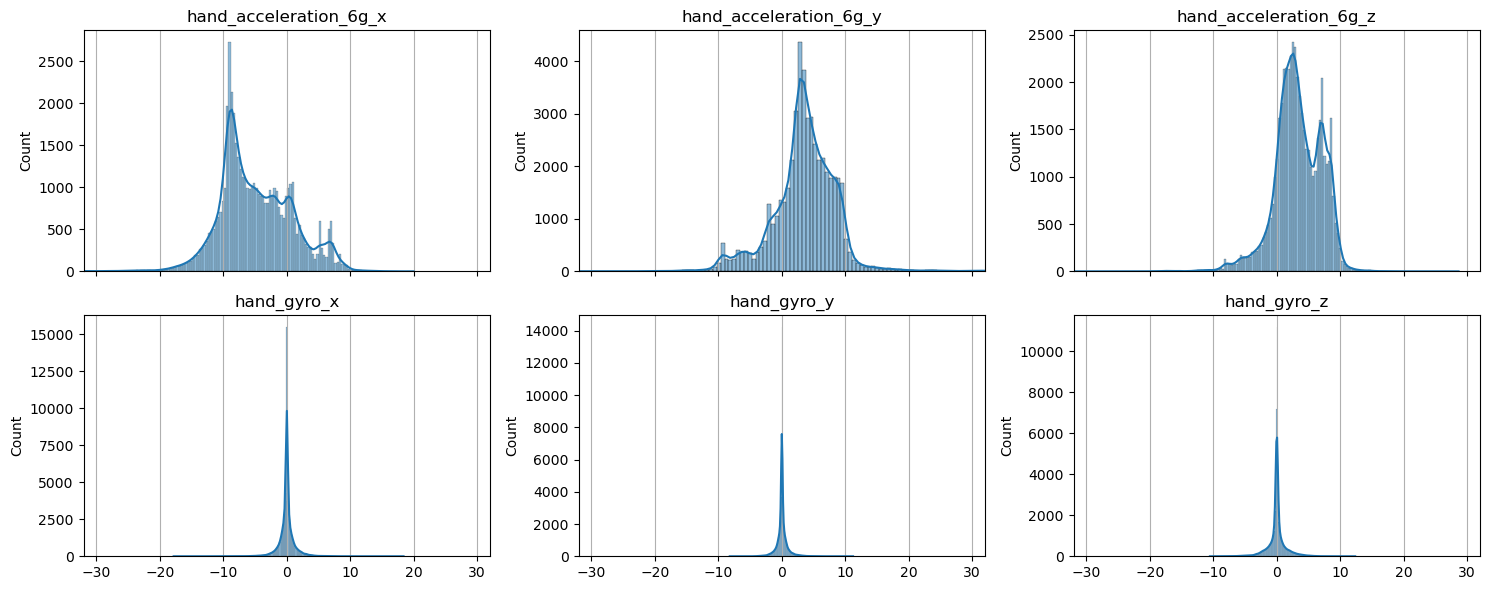

In [129]:
import seaborn as sns
from matplotlib import pyplot as plt

def plot_distributions(df, exclude_cols=None, sample_n=50_000, n_cols=3, xmin=-32, xmax=32):
    exclude_cols = exclude_cols or ['timestamp', 'subject_id', 'activity_id']
    cols = [c for c in df.columns if c not in exclude_cols]
    
    df_plot = df.sample(sample_n) if len(df) > sample_n else df
    
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.histplot(df_plot[col].dropna(), bins=200, ax=axes[i], kde=True)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].set_xlim(xmin, xmax)
        axes[i].grid(True, axis='x')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# usage
plot_distributions(resampled)